In [22]:
import os
os.chdir("../")
from src.adecuacion import corrector, ImagenHyper
from src.spacial_bin import binning
from src.labeling import identificar_muestras1, enseñar_muestras,y_prop_label_generation, y_prop_label_generation, combinar_labels, espectros_muestras
from src.rgb import img_rgb, imagen_prediccion, imagen_labelling
import matplotlib.pyplot as plt
import numpy as np
ruta1="""E:/TFM IMAGENES/IMAGENES/"""
dia='30ene2026/'
nombre_muestra='30ene2026_0002_sopela'
ruta2='/capture/'
white='WHITEREF_'
dark='DARKREF_'
extension='.hdr'

"D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
ruta_imagen=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/{nombre_muestra}{extension}"
ruta_blanco=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/WHITEREF_{nombre_muestra}{extension}"
ruta_negro=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/DARKREF_{nombre_muestra}{extension}"
imagen_sopela =corrector(ruta_imagen=ruta_imagen,ruta_blanco=ruta_blanco,ruta_negro=ruta_negro)

<>:17: SyntaxWarning:

invalid escape sequence '\T'

<>:17: SyntaxWarning:

invalid escape sequence '\T'

C:\Users\unaif\AppData\Local\Temp\ipykernel_7504\2811490746.py:17: SyntaxWarning:

invalid escape sequence '\T'

c:\Users\unaif\anaconda3\envs\TFM\Lib\site-packages\spectral\io\envi.py:187: UserWarning:

Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.



In [23]:
imagen_sopela=ImagenHyper(imagen_sopela[0],imagen_sopela[1] )

In [24]:
sopela_binned=binning(imagen_sopela,2)

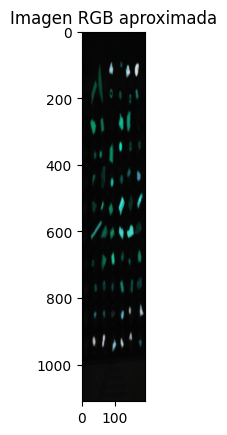

In [25]:
img_rgb(sopela_binned.img)

In [26]:
from sklearn.cluster import KMeans

from src.adecuacion import img2matrix, matrix2img, ImagenHyper, replace_from_coords

n_clusters = 5
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)
h, w, b = sopela_binned.shape
labels = kmeans.fit_predict(sopela_binned.spectra)

cluster_map=matrix2img(labels,h=h, w=w, b=1)

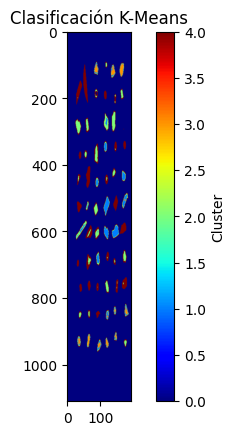

In [27]:

plt.imshow(cluster_map, cmap="jet")
plt.colorbar(label="Cluster")
plt.title("Clasificación K-Means")
plt.show()

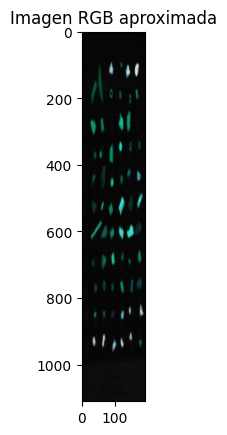

In [28]:
mask = np.argwhere(cluster_map == 0)[:,0:2]
img_rgb(replace_from_coords(sopela_binned.img, cluster_map,0))

In [29]:
mask=replace_from_coords(sopela_binned.img, mask, 0).astype(bool)[:,:,0]

In [30]:
sopela_binned.add_mask(mask=mask)

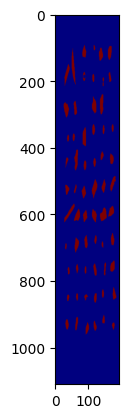

In [31]:
from skimage.morphology import erosion, disk
import matplotlib.pyplot as plt
mask_eroded = erosion(sopela_binned.mask, disk(1) )

plt.Figure(figsize=(15,15))
plt.imshow(mask_eroded, cmap="jet")

In [32]:
sopela_binned.add_mask(mask_eroded)

In [33]:
sopela_binned_sliced=sopela_binned.slicer("auto")

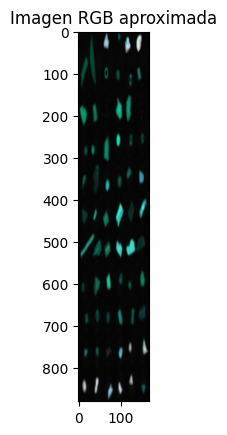

In [34]:
img_rgb(sopela_binned_sliced.img)

In [35]:
n_plasticos, props=identificar_muestras1(sopela_binned_sliced)

Plásticos detectados: 62


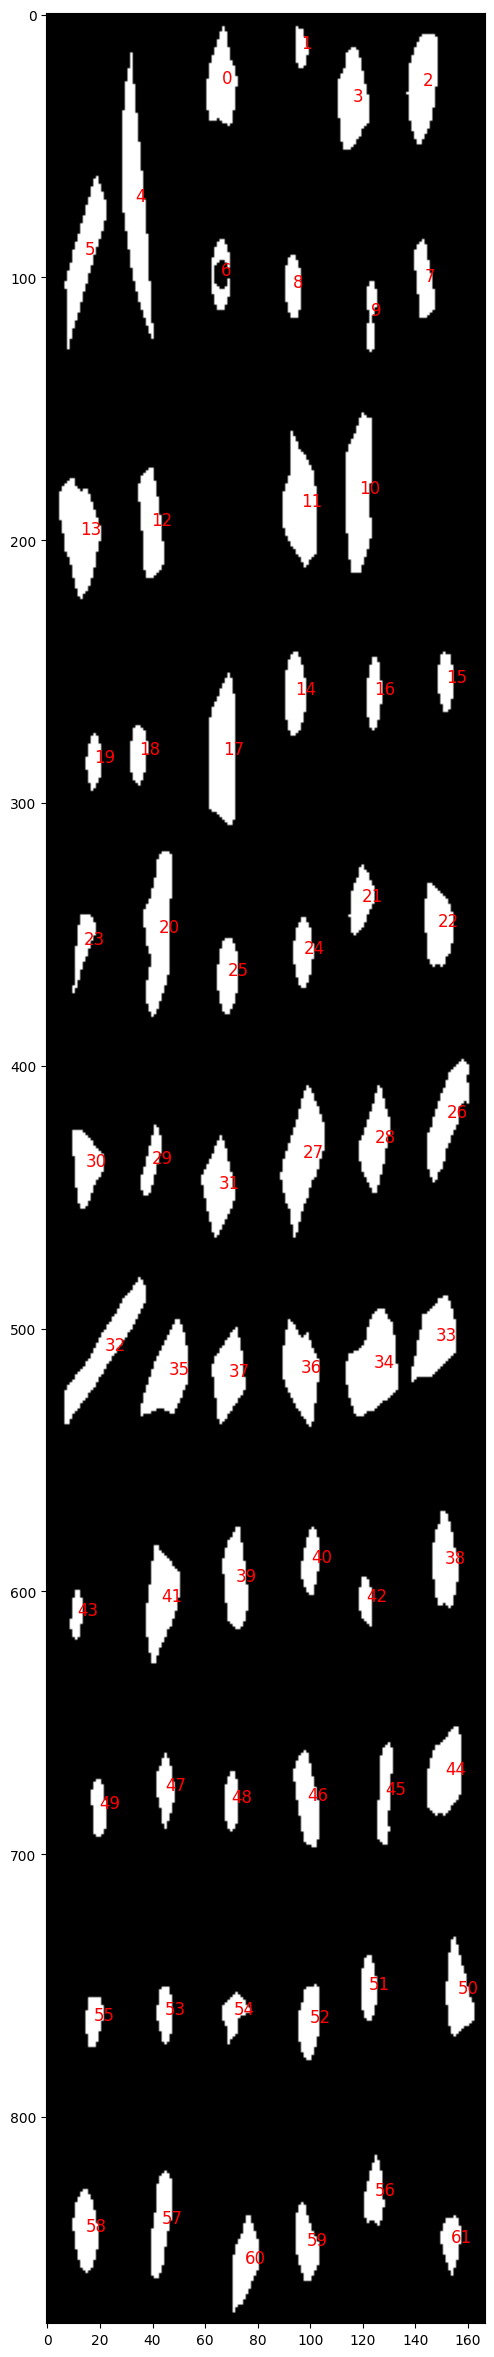

In [36]:
enseñar_muestras(sopela_binned_sliced.mask, props=props)

In [37]:
espectros_muestras(props=props, img=sopela_binned_sliced, preprocesado="SNV")

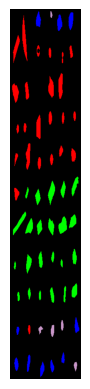

In [42]:
y_prop_label=y_prop_label_generation(n_plasticos)
y_prop_label[0:4]=3
y_prop_label[1]=0
y_prop_label[4:26]=1
y_prop_label[30]=1

y_prop_label[26:30]=2
y_prop_label[31:50]=2

y_prop_label[53]=1

y_prop_label[50]=3
y_prop_label[55]=3
y_prop_label[56:61]=3
y_prop_label
imagen_labelling(y_prop=y_prop_label, props=props, shape=sopela_binned_sliced.shape
                 )

In [39]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

In [ ]:
os.getcwd()
os.chdir()

'c:\\Users\\unaif\\TFM PYTHON\\Repositorio'

In [44]:
combinar_labels(sopela_binned_sliced,y_prop_label, props)

In [ ]:
---

In [48]:
import pickle
with open("TFM/DATA/sopela_binned_sliced.pkl", "wb") as f:
    pickle.dump(sopela_binned_sliced, f)

True